# Imports

In [21]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders import PyPDFLoader # for loading PDF file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langgraph.prebuilt import ToolNode, tools_condition # for tools conditions
# youtube search tool
from langchain_community.tools import YouTubeSearchTool
from langchain_community.document_loaders import YoutubeLoader
import ast # convert string into actual python list
# wikipedia search tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
# google search tools
import os
from langchain_community.utilities import SearchApiAPIWrapper
from langchain_core.tools import Tool
# dot env loading
from pathlib import Path
from dotenv import load_dotenv
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List

In [22]:
env_path = Path("../.env")    # go up one folder
load_dotenv(dotenv_path=env_path)

True

# model

In [23]:
llm = ChatGroq(model="qwen/qwen3-32b")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

# Tools

In [24]:
tools = []

Extract data tool.

In [25]:
@tool("extract_data")
def extract_data(pdf_path: str) -> str:
    """Extracts raw text from a PDF file."""
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()
    return "\n\n".join([doc.page_content for doc in docs])

tools.append(extract_data)

Chunk data tool

In [26]:
@tool("chunk_data")
def chunk_data(raw_text: str):
    """Chunks extracted text into smaller segments."""
    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    return splitter.split_text(raw_text)
tools.append(chunk_data)

Embed and storing results in FAISS vector db tool

In [27]:
vector_db = None

@tool("embed_and_store")
def embed_and_store(chunks: list):
    """Embeds chunks and stores them in a FAISS vector database."""
    global vector_db
    vector_db = FAISS.from_texts(chunks, embeddings)
    return "Data successfully indexed in FAISS."
tools.append(embed_and_store)

Vecot search tool

In [28]:
@tool("vector_search")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    if vector_db is None:
        return "Vector database is empty. Please index a PDF first."
    docs = vector_db.similarity_search(query, k=5)
    return "\n\n".join([d.page_content for d in docs])
tools.append(vector_search)

Youtube search

In [29]:
@tool("fetch_youtube_content", description="finds youtube videos using YoutubeSearchTool and then fetches content of the link using YoutubeLoader")
def fetch_youtube_content(query: str) -> str:
    """
    Fetches the full transcript text from a YouTube video link.
    """
    youtube_tool = YouTubeSearchTool()

    raw_result = youtube_tool.run(query)
    video_ids = ast.literal_eval(raw_result)
    links = [vid for vid in video_ids]

    all_text = ""
    i = 0
    for link in links:
      all_text += f"Video {i + 1} Content: "
      loader = YoutubeLoader.from_youtube_url(
          link,
          add_video_info=False,
      )
      doc = loader.load()
      all_text += doc[0].page_content + "\n"
      i = i + 1

    return all_text
tools.append(fetch_youtube_content)

Wikipedia search tool

In [30]:
wikiSearch = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
tools.append(wikiSearch)

google web search tool

In [31]:
# 1) Google Web Search
google_web = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google",            # standard Google web search
)

google_web_tool = Tool(
    name="google_web_search",
    description="General Google web search via SearchApi.io.",
    func=google_web.run,
)

tools.append(google_web_tool)

google news search tool

In [32]:
# 2) Google News
google_news = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_news",       # Google News vertical
)

google_news_tool = Tool(
    name="google_news_search",
    description="Latest news headlines and articles via Google News (SearchApi.io).",
    func=google_news.run,
)

tools.append(google_news_tool)

Google scholar search

In [33]:
# 3) Google Scholar
google_scholar = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_scholar",    # Google Scholar vertical
)

google_scholar_tool = Tool(
    name="google_scholar_search",
    description="Academic papers and scholarly articles via Google Scholar (SearchApi.io).",
    func=google_scholar.run,
)

tools.append(google_scholar_tool)

Binding LLM with tool

In [35]:
llm_with_tools = llm.bind_tools(tools)

lang graph state

In [36]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    rag_content: str # content from the RAG
    web_content: str # content from the web
    phase: str # current phase of the chat web or rag

# Nodes

In [37]:
def planning(state: ChatState):
    SYSTEM_PROMPT = f"""
    You are an Agentic RAG expert. Follow this EXACT sequence to answer questions:

    1. **ANALYZE**: Read the question carefully to understand what's needed
    2. **RAG FIRST**: ALWAYS try RAG retrieval first (internal knowledge base)
    3. **CHECK VECTOR DB**: Always search vector db against the search query. If you find that vector db is empty then perform all RAG operations.  
    4. **RAG SEQUENCE**: Perform full RAG sequence if vector db is empty → extract data -> chunk data -> embed and store data -> retrieve data → vector search and at the end check relevence.
    5. **IF RAG NOT GOOD**: Switch to web search → retrieve → check relevance  
    6. **LOOP UNTIL GOOD**: Keep alternating RAG ↔ Web until relevance is good
    7. **GENERATE**: ONLY when you have good relevant context, generate answer

    Question: {state['question']}
    """
    query = state["question"] + SystemMessage(content=SYSTEM_PROMPT)

    return {"messages": [query]}

In [38]:
def context_search(state: ChatState):
    
    state["phase"] = "rag"
    ai_response = llm_with_tools.invoke(state["messages"])

    return {"rag_content": ai_response.content}
        

In [39]:
def check_relevence(state: ChatState):
    phase = state["phase"]

    # Select what to judge
    if phase == "rag":
        context = state["rag_content"]
    else:
        context = state["web_content"]

    judge_prompt = f"""
    Question: {state['question']}

    Context:
    {context}

    Is this context sufficient and relevant to answer the question?
    Reply only YES or NO.
    Donot give any other explanation.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()
    state["phase"] = "web"
    if decision == "YES":
        return "END"
    else:
        return "web_search"

In [40]:
def web_search(state: ChatState):

    ai_response = llm_with_tools.invoke(state["messages"])

    return {"web_content": ai_response.content}
    

In [41]:
tool_node = ToolNode(tools)

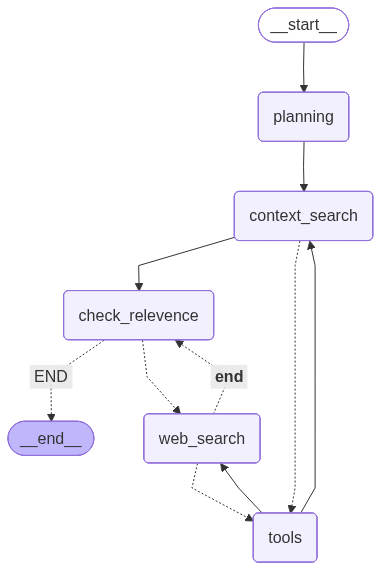

In [52]:
graph = StateGraph(ChatState)

graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node('tools', tool_node)

graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_conditional_edges('context_search', tools_condition, {"tools": "tools", "__end__": "check_relevence"})
graph.add_edge('tools', 'context_search')
graph.add_edge('context_search', 'check_relevence')
graph.add_conditional_edges("check_relevence", check_relevence, {"web_search": "web_search", "END": END})
graph.add_conditional_edges('web_search', tools_condition, {"tools": "tools", "__end__": "check_relevence"})
graph.add_edge("tools", "web_search")

chatbot = graph.compile()
chatbot

In [70]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "tell me about imran khan? using wikipedia search tool"
                )
            )
        ]
    }
)
print(result['messages'][-1].content)

<think>
Okay, the user is asking about Imran Khan and wants me to use the Wikipedia search tool. Let me start by recalling what I know about him. Imran Khan is a prominent figure in Pakistan, right? He's a former cricketer and a politician.

First, I should check his full name and birth details. I think he was born in 1952. Let me confirm that. Yes, Imran Khan was born on October 1, 1952, in Lahore, Pakistan. He's known for being a cricketer, captain of the Pakistani team, and winning the Cricket World Cup in 1992. That's a key point.

Now, moving on to his political career. He founded the Pakistan Tehreek-e-Insaf (PTI) party in 1996. I remember he became the Prime Minister of Pakistan after winning the 2018 elections. He served from August 2018 until August 2023 when he was removed from office. The reason for his removal was a vote of no confidence in April 2022, and then later, the Supreme Court disqualified him due to a legal case related to a corruption scandal. That led to his par